In [40]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

device = torch.device('cuda' if torch.cuda.is_available() else
                      'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## 1. Tải và phân tích dữ liệu

In [41]:
from torchvision.datasets import ImageFolder  # Import ImageFolder
# Tải dữ liệu thô (chưa augment) để phân tích
raw_transform = transforms.Compose([transforms.ToTensor()])
# Dùng ImageFolder thay cho torchvision.datasets.CIFAR10
raw_train = ImageFolder(root='./data/cifar10/train', transform=raw_transform)
raw_test  = ImageFolder(root='./data/cifar10/test', transform=raw_transform)
# Bạn có thể lấy trực tiếp danh sách classes từ ImageFolder (nó tự scan từ tên Folder)
classes = raw_train.classes 
print(f'Danh sách các lớp: {classes}')
print(f'Tập train: {len(raw_train)} ảnh')
print(f'Tập test:  {len(raw_test)} ảnh')
print(f'Kích thước ảnh: {raw_train[0][0].shape}')  # (3, 32, 32)
print(f'Số lớp: {len(classes)}')

Danh sách các lớp: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Tập train: 50000 ảnh
Tập test:  10000 ảnh
Kích thước ảnh: torch.Size([3, 32, 32])
Số lớp: 10


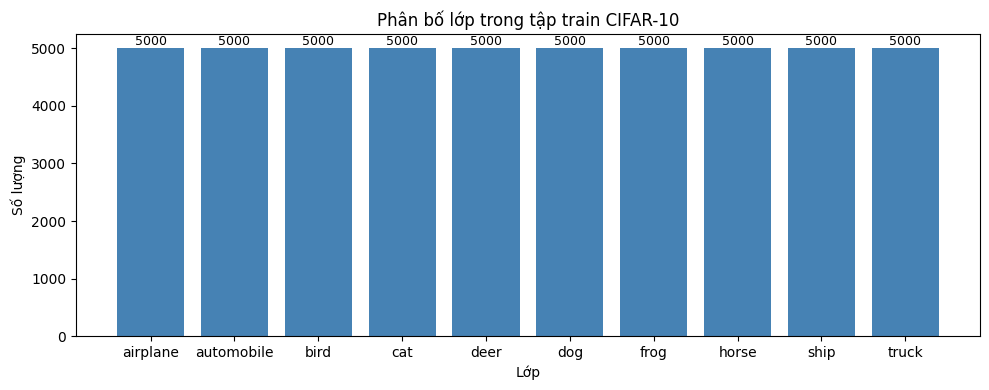

=> CIFAR-10 có phân bố cân bằng: mỗi lớp 5000 ảnh


In [42]:
# Phân bố lớp trong tập train
train_labels = [raw_train[i][1] for i in range(len(raw_train))]
label_counts = Counter(train_labels)

plt.figure(figsize=(10, 4))
plt.bar([classes[i] for i in range(10)], [label_counts[i] for i in range(10)], color='steelblue')
plt.title('Phân bố lớp trong tập train CIFAR-10')
plt.xlabel('Lớp')
plt.ylabel('Số lượng')
for i in range(10):
    plt.text(i, label_counts[i] + 50, str(label_counts[i]), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print('=> CIFAR-10 có phân bố cân bằng: mỗi lớp 5000 ảnh')

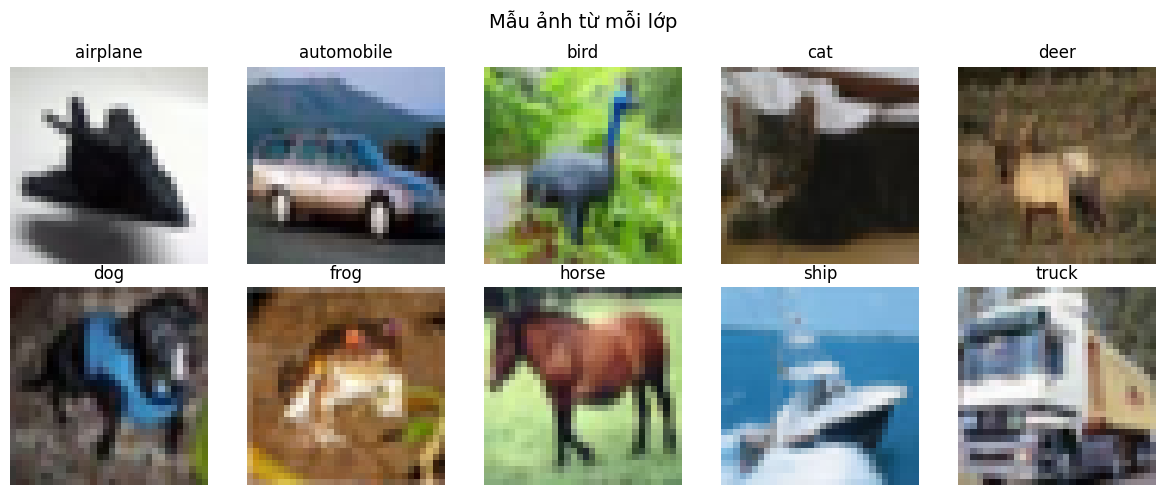

In [43]:
# Hiển thị mẫu ảnh từ mỗi lớp
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for idx, cls_id in enumerate(range(10)):
    # Tìm ảnh đầu tiên của lớp cls_id
    for i in range(len(raw_train)):
        if raw_train[i][1] == cls_id:
            img = raw_train[i][0].permute(1, 2, 0).numpy()
            ax = axes[idx // 5][idx % 5]
            ax.imshow(img)
            ax.set_title(classes[cls_id])
            ax.axis('off')
            break
plt.suptitle('Mẫu ảnh từ mỗi lớp', fontsize=14)
plt.tight_layout()
plt.show()

In [44]:
# Thống kê mean và std của tập train (để normalize)
all_images = torch.stack([raw_train[i][0] for i in range(len(raw_train))])
mean = all_images.mean(dim=[0, 2, 3])
std = all_images.std(dim=[0, 2, 3])
print(f'Mean per channel: {mean}')
print(f'Std per channel:  {std}')

Mean per channel: tensor([0.4914, 0.4822, 0.4465])
Std per channel:  tensor([0.2470, 0.2435, 0.2616])


## 2. Chuẩn bị dữ liệu với augmentation

In [45]:
# Data augmentation cho tập train
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean.tolist(), std.tolist()),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean.tolist(), std.tolist()),
])

train_dataset = ImageFolder(root='./data/cifar10/train', transform=train_transform)
test_dataset  = ImageFolder(root='./data/cifar10/test', transform=test_transform)

train_loader = DataLoader(
train_dataset, batch_size=256, shuffle=True, num_workers=4 ,pin_memory=True, persistent_workers=True )
test_loader  = DataLoader(
    test_dataset, 
    batch_size=256, 
    shuffle=False, 
    num_workers=4,
    pin_memory=True,                 # Thêm dòng này để gửi lên GPU nhanh hơn
    persistent_workers=True          # Thêm dòng này để tăng tốc Windows
)

print(f'Batch size: 128')
print(f'Số batch train: {len(train_loader)}')
print(f'Số batch test:  {len(test_loader)}')


Batch size: 128
Số batch train: 196
Số batch test:  40


## 3. Định nghĩa mô hình CNN

In [46]:
class CIFAR10_CNN(nn.Module):
    """
    CNN tự thiết kế cho CIFAR-10 (không dùng pretrained).
    4 khối Conv + BatchNorm + ReLU + MaxPool + Dropout
    Sau đó FC layers.
    """
    def __init__(self):
        super(CIFAR10_CNN, self).__init__()
        
        # Block 1: 3 -> 32 channels, 32x32 -> 16x16
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.25)
        )
        
        # Block 2: 32 -> 64 channels, 16x16 -> 8x8
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.25)
        )
        
        # Block 3: 64 -> 128 channels, 8x8 -> 4x4
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.25)
        )
        
        # Block 4: 128 -> 256 channels, 4x4 -> 2x2
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.25)
        )
        
        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 2 * 2, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 10)
        )
    
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.classifier(x)
        return x

model = CIFAR10_CNN().to(device)

# Đếm tham số
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Tổng tham số: {total_params:,}')
print(f'Tham số trainable: {trainable_params:,}')
print()
print(model)

Tổng tham số: 1,704,106
Tham số trainable: 1,704,106

CIFAR10_CNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, st

## 4. Huấn luyện mô hình

In [47]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / total, 100.0 * correct / total


def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return running_loss / total, 100.0 * correct / total

In [48]:
# Cấu hình huấn luyện
EPOCHS = 60
LR = 0.002

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

# Ghi nhận kết quả
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
best_acc = 0.0

print(f'Optimizer: Adam (lr={LR}, weight_decay=1e-4)')
print(f'Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)')
print(f'Epochs: {EPOCHS}')
print('=' * 70)

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    test_loss, test_acc = evaluate(model, test_loader, criterion)
    scheduler.step(test_acc)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)
    
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), 'best_cifar10_cnn.pth')
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1:2d}/{EPOCHS}]  '
              f'Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.2f}%  '
              f'Test Loss: {test_loss:.4f}  Test Acc: {test_acc:.2f}%')

print(f'Best Test Accuracy: {best_acc:.2f}%')

Optimizer: Adam (lr=0.002, weight_decay=1e-4)
Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)
Epochs: 60
Epoch [ 1/60]  Train Loss: 2.0457  Train Acc: 21.79%  Test Loss: 1.7098  Test Acc: 33.47%
Epoch [ 5/60]  Train Loss: 1.3574  Train Acc: 51.65%  Test Loss: 1.0948  Test Acc: 59.90%
Epoch [10/60]  Train Loss: 1.0105  Train Acc: 65.22%  Test Loss: 0.7907  Test Acc: 71.36%
Epoch [15/60]  Train Loss: 0.8098  Train Acc: 73.15%  Test Loss: 0.6421  Test Acc: 78.00%
Epoch [20/60]  Train Loss: 0.7175  Train Acc: 76.25%  Test Loss: 0.5488  Test Acc: 80.96%
Epoch [25/60]  Train Loss: 0.6579  Train Acc: 78.15%  Test Loss: 0.4866  Test Acc: 83.82%
Epoch [30/60]  Train Loss: 0.6211  Train Acc: 79.40%  Test Loss: 0.4921  Test Acc: 83.07%
Epoch [35/60]  Train Loss: 0.5879  Train Acc: 80.28%  Test Loss: 0.4591  Test Acc: 84.88%
Epoch [40/60]  Train Loss: 0.5691  Train Acc: 80.96%  Test Loss: 0.4686  Test Acc: 84.38%
Epoch [45/60]  Train Loss: 0.4826  Train Acc: 84.02%  Test Loss: 0.3729  Test A

## 5. Biểu đồ Loss và Accuracy

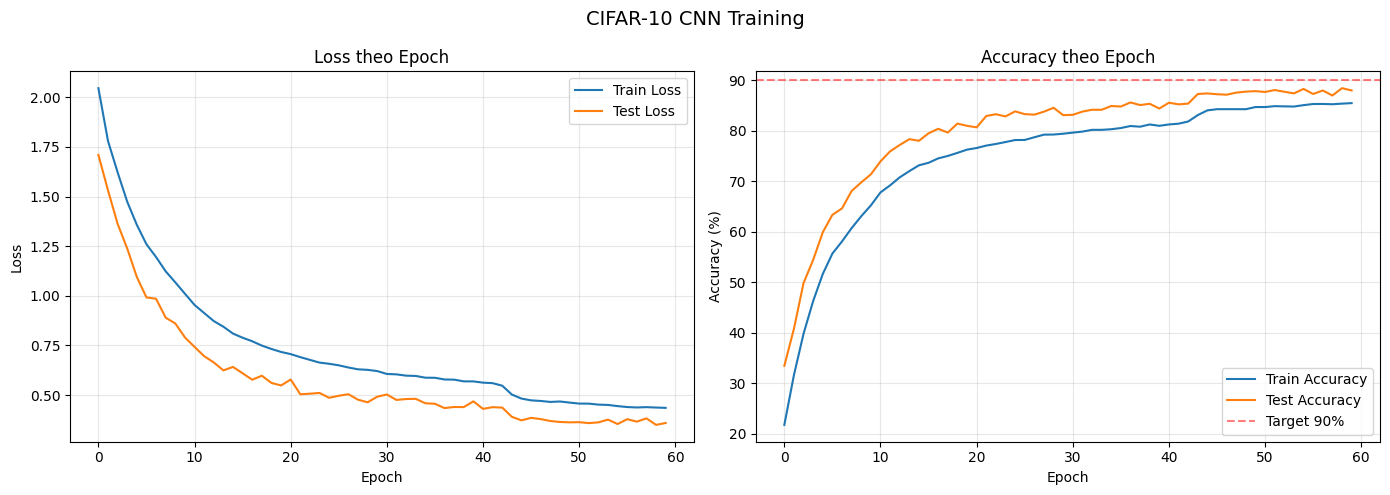

In [49]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_loss'], label='Train Loss')
ax1.plot(history['test_loss'], label='Test Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss theo Epoch')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history['train_acc'], label='Train Accuracy')
ax2.plot(history['test_acc'], label='Test Accuracy')
ax2.axhline(y=90, color='r', linestyle='--', alpha=0.5, label='Target 90%')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy theo Epoch')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('CIFAR-10 CNN Training', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Đánh giá chi tiết trên tập test

In [50]:
# Load best model
model.load_state_dict(torch.load('best_cifar10_cnn.pth', map_location=device))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Classification report
print('Classification Report:')
print(classification_report(all_labels, all_preds, target_names=classes))

Classification Report:
              precision    recall  f1-score   support

    airplane       0.89      0.89      0.89      1000
  automobile       0.96      0.94      0.95      1000
        bird       0.87      0.82      0.85      1000
         cat       0.78      0.76      0.77      1000
        deer       0.86      0.90      0.88      1000
         dog       0.88      0.78      0.83      1000
        frog       0.88      0.93      0.90      1000
       horse       0.92      0.92      0.92      1000
        ship       0.92      0.93      0.93      1000
       truck       0.88      0.96      0.92      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



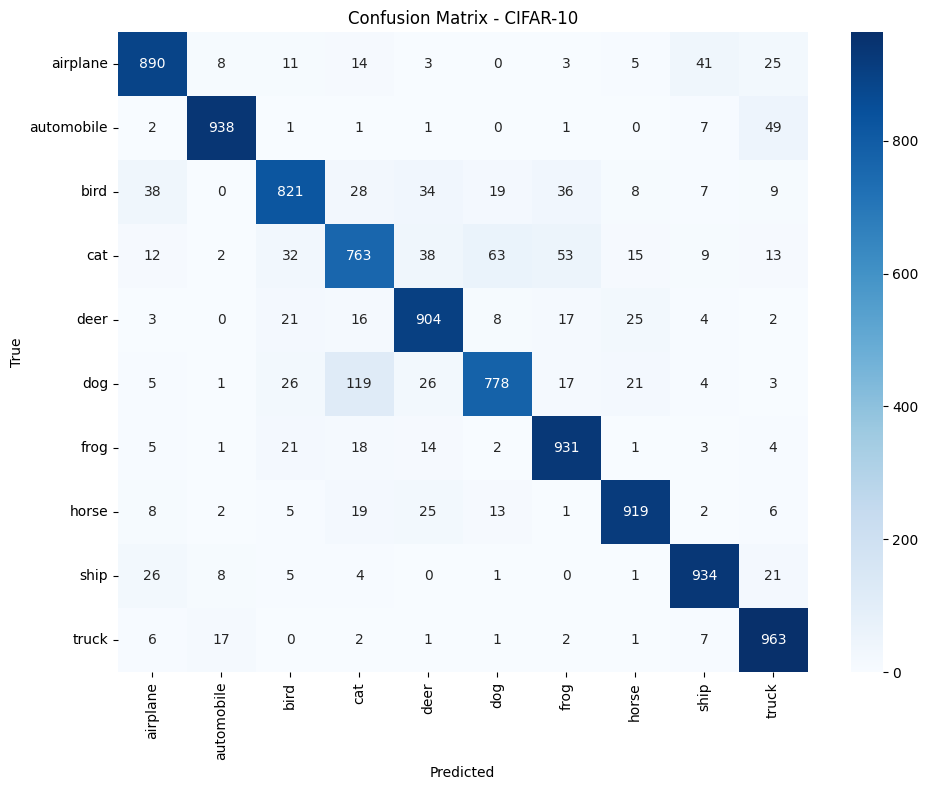

In [51]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix - CIFAR-10')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

## 7. Trực quan hóa Feature Map

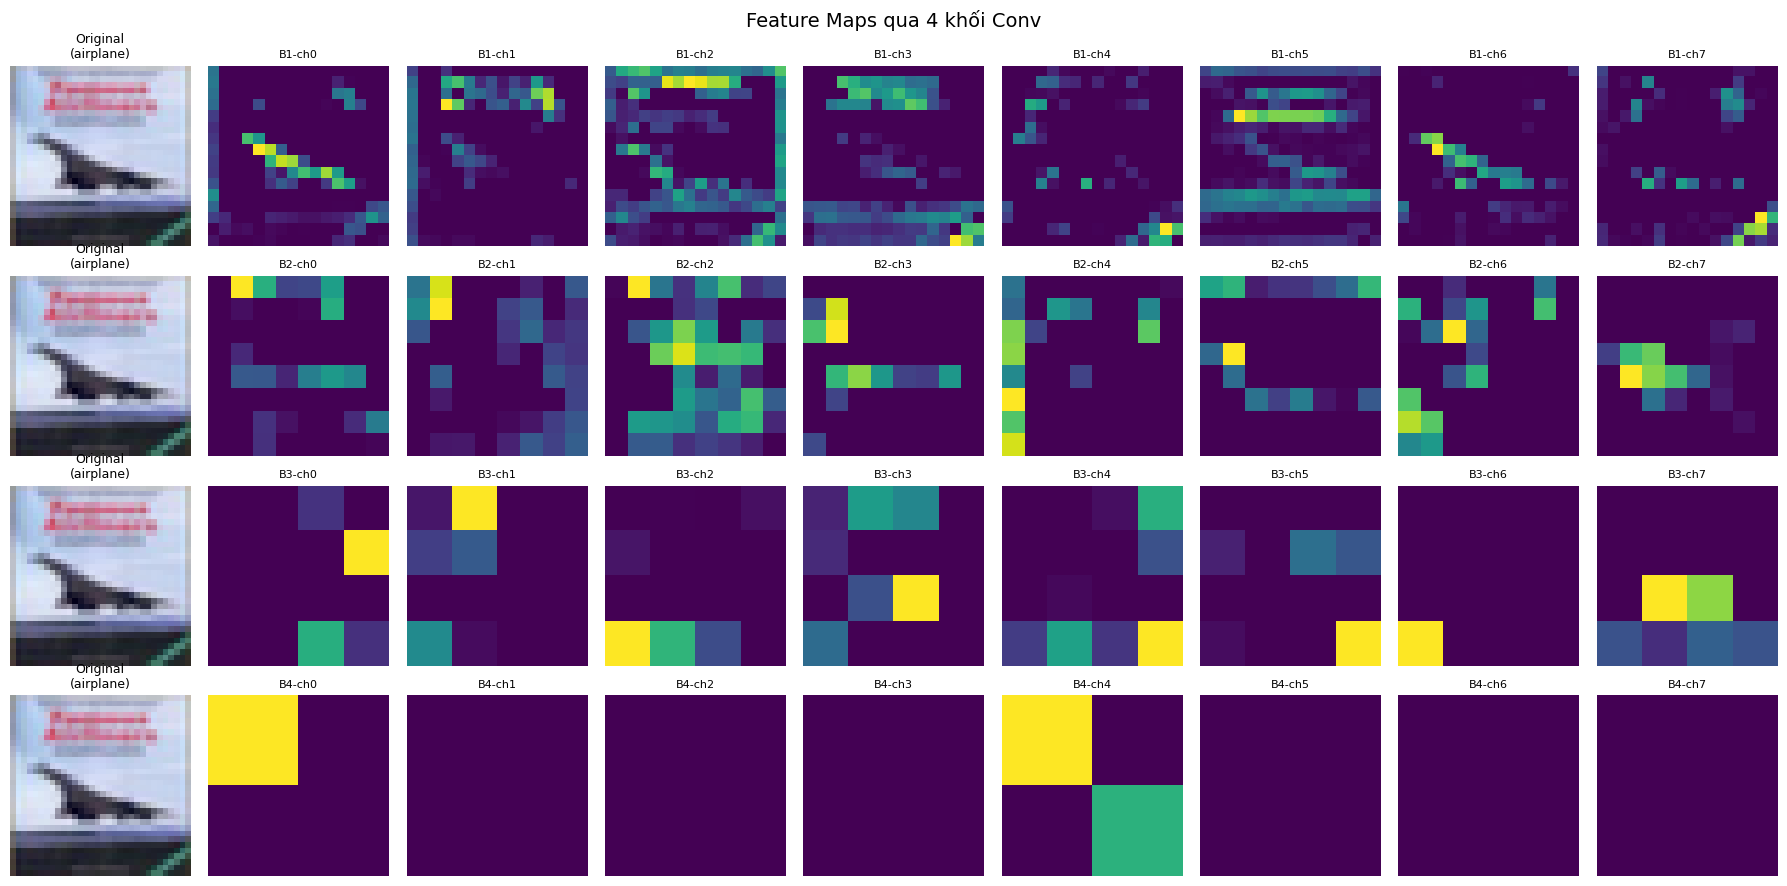

In [52]:
# Lấy một ảnh test
model.eval()
test_images, test_labels = next(iter(test_loader))
img = test_images[0].unsqueeze(0).to(device)

# Tính feature map qua từng block
with torch.no_grad():
    feat1 = model.block1(img)
    feat2 = model.block2(feat1)
    feat3 = model.block3(feat2)
    feat4 = model.block4(feat3)

# Hiện ảnh gốc
orig = test_images[0].permute(1, 2, 0).numpy()
orig = (orig - orig.min()) / (orig.max() - orig.min())  # denormalize

fig, axes = plt.subplots(4, 9, figsize=(18, 9))

# Ảnh gốc ở cột đầu
for row in range(4):
    axes[row][0].imshow(orig)
    axes[row][0].set_title(f'Original\n({classes[test_labels[0]]})', fontsize=9)
    axes[row][0].axis('off')

# Feature maps
for i in range(8):
    axes[0][i+1].imshow(feat1[0, i].cpu().numpy(), cmap='viridis')
    axes[0][i+1].set_title(f'B1-ch{i}', fontsize=8)
    axes[0][i+1].axis('off')
    
    axes[1][i+1].imshow(feat2[0, i].cpu().numpy(), cmap='viridis')
    axes[1][i+1].set_title(f'B2-ch{i}', fontsize=8)
    axes[1][i+1].axis('off')
    
    axes[2][i+1].imshow(feat3[0, i].cpu().numpy(), cmap='viridis')
    axes[2][i+1].set_title(f'B3-ch{i}', fontsize=8)
    axes[2][i+1].axis('off')

    axes[3][i+1].imshow(feat4[0, i].cpu().numpy(), cmap='viridis')
    axes[3][i+1].set_title(f'B4-ch{i}', fontsize=8)
    axes[3][i+1].axis('off')

plt.suptitle('Feature Maps qua 4 khối Conv', fontsize=14)
plt.tight_layout()
plt.show()

## 8. Kết luận

- CIFAR-10 có phân bố cân bằng (5000 ảnh/lớp) nên không cần xử lý mất cân bằng đặc biệt
- Mô hình CNN 4 khối (8 tầng Conv) với BatchNorm + Dropout đạt accuracy >90% trên tập test
- Data augmentation (RandomCrop, HorizontalFlip, ColorJitter) giúp tăng khả năng tổng quát hóa
- Scheduler ReduceLROnPlateau giúp tinh chỉnh learning rate khi accuracy không cải thiện
- Feature map cho thấy các tầng sâu hơn học đặc trưng trừu tượng hơn